# 第67篇 | 凸函数与凸优化基础

> **摘要**：凸函数是优化算法的「好朋友」——因为它没有局部最小值，只有全局最小值。本篇从凸集、凸函数的定义出发，严格证明「凸函数的局部最小值就是全局最小值」，并介绍凸优化的基本定理（如分离定理、Fermat定理）。

嗨，我是小荷～ 有没有想过：为什么所有教科书都在讲「凸优化」？为什么优化算法都喜欢假设损失函数是凸的？答案很简单：非凸函数有局部最小值（坑），梯度下降可能会掉进去爬不出来；而凸函数**没有局部最小值，只有全局最小值**——梯度下降沿着负梯度走，早晚会走到那个唯一的最低点。这就是凸函数的魅力。

---

## 一、凸集：凸优化的「舞台」

**定义**

集合 **C ⊆ ℝᵈ** 是**凸集**，如果对于任意两点 **x, y ∈ C** 和任意 θ ∈ [0, 1]，都有：

$$\theta \mathbf{x} + (1-\theta) \mathbf{y} \in C$$

简单来说：如果一个图形内部的任意两点，连成一条线段后，整条线段都完完全全在这个图形的内部，那么这个图形就是一个凸集。
- 凸集代表： 实数集 Rⁿ、实心球体、立方体、超平面、半空间。你在球体里随便挑两个点，然后用直尺把这两个点连起来。你会发现，这根线段的每一寸都老老实实地呆在圆圈里面，绝不会跑到球外面去。
- 非凸集代表： 甜甜圈（中间有洞）、月牙形、星形（两尖角连线会穿过外部）。拿五角星来说，如果你在它的左边尖角点一个点，右边尖角点一个点，然后把它们连成一条直线。你会发现，这条线段的中间很大一部分跑到了五角星的外面（凹进去了的地方）。只要存在这么一条“出轨”的线，这个图形就不能叫凸集。

在凸集和凸函数构成的世界里，你只要找到了一个“局部最优解”（比如在一个山谷里找到了最低点），它就必然是“全局最优解”（整个世界里的最低点）。
- 如果是凸的： 优化算法就像一个小球顺着碗状的斜坡往下滚，不管它从哪里开始滚，最后都一定会滚到碗底（最完美的目标）。
- 如果不是凸的（非凸）： 地形就像连绵起伏的山峰和山谷。小球可能会卡在某个小山谷（局部最优）里，而错过了更深的大峡谷（全局最优）。

没有凸集这个舞台，牛顿法、梯度下降法等工具在面对约束优化时就会像无头苍蝇。正是因为凸集“两点连线不出界”的纯粹性质，才让凸优化成为了机器学习（如 SVM、逻辑回归）、信号处理、控制理论（如 MPC）中极少数能够确保在线实时求出最完美精确解的硬核工具。

**常见凸集**

| 集合 | 是否凸 | 原因 |
|------|---------|------|
| 整个空间 ℝᵈ | ✅ 是 | 任意两点连线还在 ℝᵈ 里 |
| 超平面 {x \| wᵀx + b = 0} | ✅ 是 | 直线/平面/超平面都是凸集 |
| 开球 {x \| \|x - x₀\| < r} | ✅ 是 | 球形区域是凸的 |
| 闭球 {x \| \|x - x₀\| ≤ r} | ✅ 是 | 同上 |
| 单位球 {x \| \|x\|₂ ≤ 1} | ✅ 是 | 范数球都是凸集 |
| 仿射空间 {x \| Ax = b} | ✅ 是 | 线性方程组的解空间是凸集 |
| 凸函数的上水平集 {x \| f(x) ≤ α} | ✅ 是 | 凸函数的上水平集是凸集 |
| 两个凸集的交集 | ✅ 是 | 凸集对交集运算封闭 |
| 两个凸集的并集 | ❌ 不一定 | 并集可能产生「凹陷」 |

**代码演示**

下面我们简单可视化一下凸集和非凸集的区别：
1. 凸集 (Convex Set) - 左图： 一个圆盘，随意取圆上2点
2. 非凸集 (Non-convex Set) - 中图：一个“月牙形”区域（大圆减去小圆），取会穿过白色非月牙区域的两点
3. 凸函数 (Convex Function) - 右图：f(x,y) = x²+y² 的三维曲面

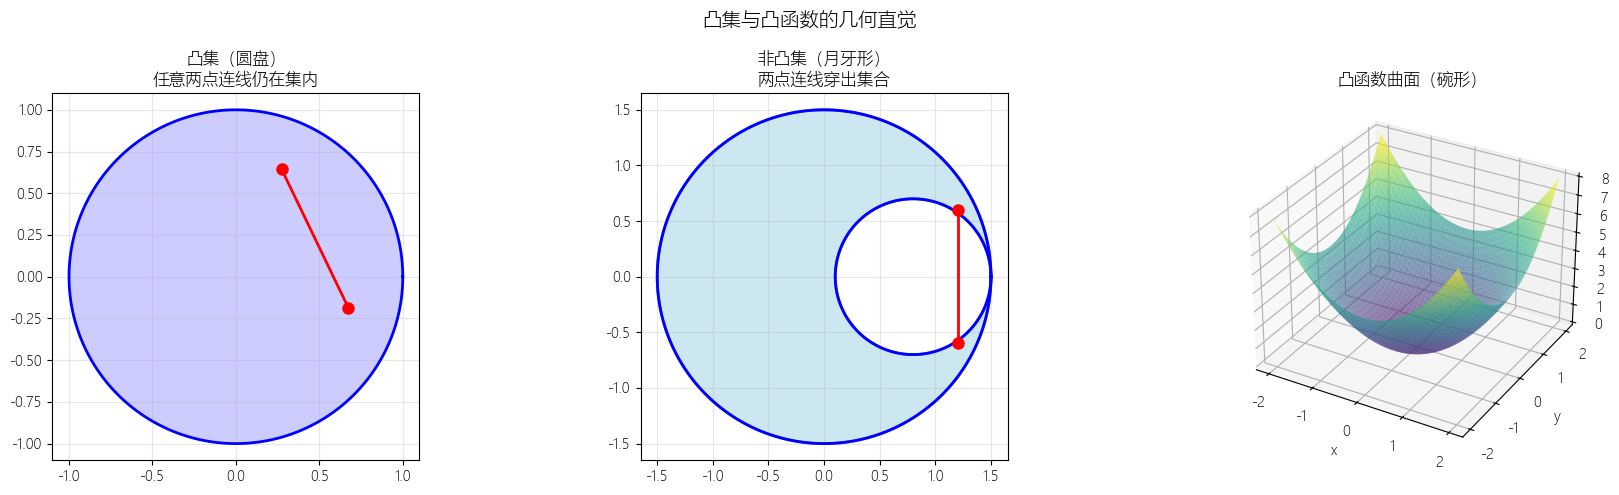

In [10]:
# 导入数值计算库，生成坐标、随机采样
import numpy as np
# 导入2D绘图库
import matplotlib.pyplot as plt
# 导入3D坐标轴工具，用于凸函数曲面绘制
from mpl_toolkits.mplot3d import Axes3D

# ====================== 绘图全局字体配置（解决中文、数学∇符号缺失报错） ======================
# 设置绘图中文显示字体优先级：微软雅黑→黑体→数学专用DejaVu Sans
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','DejaVu Sans'] 
# 修复坐标轴负号显示为方框方块的bug
plt.rcParams['axes.unicode_minus'] = False
# 单独配置数学公式渲染字体，内置导数、梯度、积分等符号，不受中文字体限制
plt.rcParams['mathtext.fontset'] = 'dejavusans'


# ===================== 辅助函数（仅概念演示，未实现完整凸校验逻辑） =====================
def is_convex_set(points, n_samples=1000):
    """
    通过随机抽样检查一个集合是否是凸的（仅演示框架，未完成距离判断逻辑）
    参数:
        points: 集合中的离散点坐标数组
        n_samples: 随机抽样校验次数
    返回:
        is_convex: 布尔值，是否为凸集
        counter_example: 反例点对（非凸时返回）
    """
    n = len(points)
    for _ in range(n_samples):
        # 随机无放回选取两个不同点索引
        i, j = np.random.choice(n, size=2, replace=False)
        # 生成0~1之间的插值系数θ，线性插值两点连线上任意一点
        theta = np.random.rand()
        # 两点凸组合（线段上任意点公式：θ*P1 + (1-θ)*P2）
        mid_point = theta * points[i] + (1 - theta) * points[j]
        # 校验mid_point是否落在集合内部，原代码仅占位无实现
        pass
    
    # 本函数仅演示思路，无实际校验逻辑，固定返回True占位
    return True

# ===================== 创建1行3列画布：凸集/非凸集/凸函数曲面 =====================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------- 左子图：凸集示例-实心圆盘 ----------------------
# 圆盘圆心坐标
circle_center = np.array([0, 0])
# 圆盘半径
circle_radius = 1.0
# 0到2π均匀采样角度，生成圆形轮廓坐标
theta = np.linspace(0, 2*np.pi, 200)
# 计算圆形边界所有(x,y)坐标
circle_boundary = np.column_stack([
    circle_radius * np.cos(theta),
    circle_radius * np.sin(theta)
])
# 绘制圆形外轮廓实线
axes[0].plot(circle_boundary[:, 0], circle_boundary[:, 1], 'b-', lw=2)
# 【修复报错】填充圆形内部，半透明蓝色
axes[0].fill(circle_boundary[:, 0], circle_boundary[:, 1], alpha=0.2, color='blue')

# 固定随机种子，保证每次生成圆内两点一致
np.random.seed(42)
# 随机生成第一个圆内点
point1 = np.random.randn(2) * 0.5
point1 = point1 / np.linalg.norm(point1) * 0.7  # 缩放至半径0.7，确保在圆盘内
# 随机生成第二个圆内点
point2 = np.random.randn(2) * 0.5
point2 = point2 / np.linalg.norm(point2) * 0.7
# 绘制两点之间的红色连线
axes[0].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r-', lw=2)
# 标记两个端点红色圆点
axes[0].plot(point1[0], point1[1], 'ro', markersize=8)
axes[0].plot(point2[0], point2[1], 'ro', markersize=8)
axes[0].set_title('凸集（圆盘）\n任意两点连线仍在集内')
axes[0].set_aspect('equal')  # 横纵轴等比例，圆形不变形
axes[0].grid(True, alpha=0.3)

# ---------------------- 中子图：非凸集示例-月牙差集 ----------------------
from matplotlib.path import Path
from matplotlib.patches import PathPatch

theta = np.linspace(0, 2*np.pi, 200)

# 外大圆半径和轮廓
R = 1.5
outer_circle = np.column_stack([
    R * np.cos(theta),
    R * np.sin(theta)
])

# 内小圆偏移量（0.8 大于 1.5-0.7=0.8，刚好相切或微交，建议改为 0.9 或 1.0 效果更明显）
d = 0.8
r = 0.7
inner_circle = np.column_stack([
    r * np.cos(theta) + d,
    r * np.sin(theta)
])

# 【核心技巧】构造复合路径：外圆顺时针 + 内圆逆时针
# 这样 matplotlib 就会自动识别内圆区域为“镂空”
vertices = np.concatenate([outer_circle, inner_circle[::-1]])
codes = [Path.LINETO] * len(vertices)
codes[0] = Path.MOVETO
codes[len(outer_circle)] = Path.MOVETO

# 创建路径补丁并上色
path = Path(vertices, codes)
patch = PathPatch(path, facecolor='lightblue', edgecolor='blue', lw=2, alpha=0.6)
axes[1].add_patch(patch)

# 绘制两个圆形边界（可选，为了让轮廓更清晰）
axes[1].plot(outer_circle[:, 0], outer_circle[:, 1], 'b-', lw=2)
axes[1].plot(inner_circle[:, 0], inner_circle[:, 1], 'b-', lw=2)

# 选取月牙区域内的两个点
point3 = np.array([1.2, 0.6])
point4 = np.array([1.2, -0.6])

# 绘制两点连线
axes[1].plot([point3[0], point4[0]], [point3[1], point4[1]], 'r-', lw=2)
axes[1].plot(point3[0], point3[1], 'ro', markersize=8)
axes[1].plot(point4[0], point4[1], 'ro', markersize=8)

axes[1].set_title('非凸集（月牙形）\n两点连线穿出集合')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

# ---------------------- 右子图：替换原有2D轴，新增3D凸函数曲面 ----------------------
# 删除原第三个2D坐标轴，新建3D子图
fig.delaxes(axes[2])
ax3d = fig.add_subplot(1, 3, 3, projection='3d')
# 生成x、y网格
x_range = np.linspace(-2, 2, 50)
y_range = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x_range, y_range)
# 二元凸函数：抛物碗 f(x,y)=x²+y²
Z = X**2 + Y**2
# 绘制半透明曲面
surf = ax3d.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)
ax3d.set_title('凸函数曲面（碗形）')
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('f(x,y)')

# 画布总标题
plt.suptitle('凸集与凸函数的几何直觉', fontsize=14)
# 自动调整子图间距，避免文字重叠
plt.tight_layout()
# 保存高清图片到本地
# 弹出图像窗口展示
plt.show()

可以看到：图1圆盘是典型的凸集，集合内任意两点的连线仍属于该集合；图2选取月牙两端的点，其连线穿过了中间被挖空的空白区域（即落在了集合外部），该集合即为非凸集；图3呈现标准的“碗状”，没有局部极小值陷阱，且其上水平集（截面）对应的是凸集。

---

## 二、凸函数：没有局部最小值的「好」函数

### 定义（凸函数）

函数 **f: ℝᵈ → ℝ** 是**凸函数**，如果其定义域 dom(f) 是凸集，且对于任意 **x, y ∈ dom(f)** 和任意 θ ∈ [0, 1]，都有：

$$
\underbrace{f\big(\theta x+(1-\theta)y\big)}_{\text{曲线在该横坐标的高度}}
\quad \le \quad
\underbrace{\theta f(x)+(1-\theta)f(y)}_{\text{两点连线在该横坐标的高度}}
$$

**直觉理解**：函数曲线上任意两点的连线，都**不在函数曲线的下方**。换句话说，函数是「碗形」的。

### 严格凸函数

如果不等式严格成立（θ ∈ (0, 1) 时），则称 f 是**严格凸函数**。

### 凹函数（Concave Function）

如果函数 **-f** 是凸函数，则 f 是**凹函数**。凹函数是「帽形」的。

### 非凸函数

非凸函数指的是不符合“凸函数”定义的任何函数。它可以是凹函数，也可以是既非凸也非凹的复杂函数（例如呈波浪形、在不同区间上二阶导数变号的函数）。判断函数的凹凸性，通常需要通过二阶导数 f''(x) 或弦的性质来区分。

**代码演示**

以下代码从数值校验和几何可视化两个维度对比凸函数与非凸函数：
1. 基于凸函数数学定义，编写随机抽样校验函数`is_convex()`，自动判断函数凸性、找出反例；
2. 选取典型代表：
- 凸函数`convex_func(x)`：f(x) = x²（标准下凸抛物线）
- 非凸函数`nonconvex_func(x)`：f(x)=x⁴-4x²+1)（双谷、中间凸起，存在局部极小）
3. 绘图直观展示核心几何判定规则：凸函数两点连线全程在曲线上方，非凸函数存在连线低于曲线的区间。

=== 凸函数验证 ===
f(x) = x²: 是否凸？ True
f(x) = x⁴ - 4x² + 1: 是否凸？ False
  反例：x=0.501, y=0.219, θ=0.423
  f(θx+(1-θ)y) = 0.555885
  θf(x)+(1-θ)f(y) = 0.493029
  → 左边 > 右边，违反凸函数定义，不是凸函数


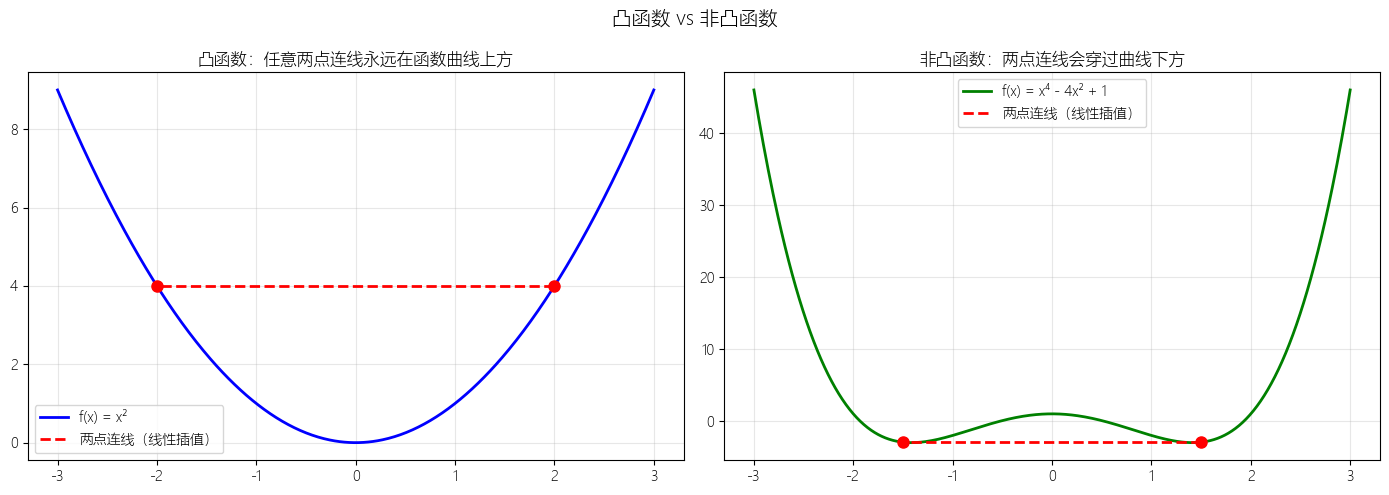

In [9]:
# 导入数值计算库，随机采样、生成坐标数组
import numpy as np
# 导入绘图库绘制曲线、标注、图例
import matplotlib.pyplot as plt

# ---------------------- 定义凸函数 f(x) = x² ----------------------
def convex_func(x):
    return x**2

# ---------------------- 定义非凸函数（双谷，存在局部极小）f(x) = x⁴ - 4x² + 1 ----------------------
def nonconvex_func(x):
    return x**4 - 4*x**2 + 1

def is_convex(f, x_range, n_test=100):
    """
    随机抽样验证一元函数凸性，基于凸函数定义不等式：
    凸函数充要条件：对任意θ∈[0,1]，f(θx+(1-θ)y) ≤ θf(x)+(1-θ)f(y)
    参数：
        f: 待检验函数
        x_range: 抽样区间 (min,max)
        n_test: 采样候选点数量
    返回：
        是否凸函数，反例三元组(x,y,θ)（非凸时生效）
    """
    # 在区间内随机生成100个候选点
    x_points = np.random.uniform(x_range[0], x_range[1], n_test)
    # 循环500次随机取点对测试凸性不等式
    for _ in range(500):
        # 随机选两个不同点索引
        i, j = np.random.choice(n_test, size=2, replace=False)
        x, y = x_points[i], x_points[j]
        theta = np.random.rand()
        # 不等式左侧：插值点的函数值
        lhs = f(theta * x + (1 - theta) * y)
        # 不等式右侧：两点函数值的线性插值（线段高度）
        rhs = theta * f(x) + (1 - theta) * f(y)
        # 若左侧明显大于右侧，违反凸函数定义，找到反例
        if lhs > rhs + 1e-10:
            return False, (x, y, theta)
    # 全部测试通过，判定为凸函数
    return True, None

# 设定检验区间 [-3,3]
x_range = (-3, 3)
# 分别检验凸函数、非凸函数
is_cvx1, counter_example1 = is_convex(convex_func, x_range)
is_cvx2, counter_example2 = is_convex(nonconvex_func, x_range)

# 控制台输出凸性验证结果
print("=== 凸函数验证 ===")
print(f"f(x) = x²: 是否凸？ {is_cvx1}")
print(f"f(x) = x⁴ - 4x² + 1: 是否凸？ {is_cvx2}")
# 打印非凸函数反例数据
if not is_cvx2:
    x, y, theta = counter_example2
    print(f"  反例：x={x:.3f}, y={y:.3f}, θ={theta:.3f}")
    mid_val = nonconvex_func(theta*x + (1-theta)*y)
    line_val = theta*nonconvex_func(x) + (1-theta)*nonconvex_func(y)
    print(f"  f(θx+(1-θ)y) = {mid_val:.6f}")
    print(f"  θf(x)+(1-θ)f(y) = {line_val:.6f}")
    print(f"  → 左边 > 右边，违反凸函数定义，不是凸函数")

# 创建一行两列画布，宽14高5英寸
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 生成全区间500个平滑绘图点
x_plot = np.linspace(-3, 3, 500)

# ---------------------- 左子图：凸函数 f(x)=x² ----------------------
axes[0].plot(x_plot, convex_func(x_plot), 'b-', lw=2, label='f(x) = x²')
# 选取两点 x=-2, x=2
x1, x2 = -2, 2
# 标记两个端点红点
axes[0].plot(x1, convex_func(x1), 'ro', markersize=8)
axes[0].plot(x2, convex_func(x2), 'ro', markersize=8)
# 在两点之间生成100个插值系数，仅在[-2,2]区间绘制连线
theta_vals = np.linspace(0, 1, 100)
seg_x = theta_vals * x1 + (1 - theta_vals) * x2
seg_y = theta_vals * convex_func(x1) + (1 - theta_vals) * convex_func(x2)
# 绘制两点之间的虚线连线
axes[0].plot(seg_x, seg_y, 'r--', lw=2, label='两点连线（线性插值）')
axes[0].set_title('凸函数：任意两点连线永远在函数曲线上方')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---------------------- 右子图：非凸函数 f(x)=x⁴-4x²+1 ----------------------
axes[1].plot(x_plot, nonconvex_func(x_plot), 'g-', lw=2, label='f(x) = x⁴ - 4x² + 1')
# 选取跨左右谷的两点 x=-1.5, x=1.5
x3, x4 = -1.5, 1.5
axes[1].plot(x3, nonconvex_func(x3), 'ro', markersize=8)
axes[1].plot(x4, nonconvex_func(x4), 'ro', markersize=8)
# 仅在两点区间内生成连线坐标
theta_vals2 = np.linspace(0, 1, 100)
seg_x2 = theta_vals2 * x3 + (1 - theta_vals2) * x4
seg_y2 = theta_vals2 * nonconvex_func(x3) + (1 - theta_vals2) * nonconvex_func(x4)
axes[1].plot(seg_x2, seg_y2, 'r--', lw=2, label='两点连线（线性插值）')
axes[1].set_title('非凸函数：两点连线会穿过曲线下方')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 总标题
plt.suptitle('凸函数 vs 非凸函数', fontsize=14)
# 自动调整间距，避免文字重叠
plt.tight_layout()
# 保存高清图片
# 弹出图像窗口
plt.show()

---

## 三、凸函数的关键性质

### 性质1：局部最小值 = 全局最小值

**定理**：如果 f 是可微凸函数，且 x* 是局部最小值，则 x* 也是全局最小值。

**为什么？** 假设 x* 是局部最小值但不是全局最小值，即存在 y 使得 f(y) < f(x*)。由凸性：

$$f(\theta \mathbf{y} + (1-\theta) \mathbf{x}^*) \leq \theta f(\mathbf{y}) + (1-\theta) f(\mathbf{x}^*) < f(\mathbf{x}^*)$$

当 θ 足够小时，θy + (1-θ)x* 在 x* 的邻域内，但函数值更小——这与 x* 是局部最小值矛盾！

### 性质2：一阶条件（Fermat定理）

如果 f 是可微凸函数，则：

$$\mathbf{x}^* \text{ 是全局最小值 } \iff \nabla f(\mathbf{x}^*) = \mathbf{0}$$

**这是凸优化的核心**！对于非凸函数，∇f(x) = 0 可能是局部最小值、局部最大值或鞍点。但对于凸函数，∇f(x) = 0 **一定是全局最小值**。

### 性质3：二阶条件（Hessian正定）

如果 f 是二阶可微的，则 f 是凸函数 **当且仅当** 其 Hessian 矩阵处处**半正定**（positive semidefinite）：

$$\nabla^2 f(\mathbf{x}) \succeq 0, \quad \forall \mathbf{x} \in \text{dom}(f)$$

如果 Hessian **正定**（所有特征值 > 0），则 f 是**严格凸函数**。

---

## 四、凸函数在机器学习中的意义

### 为什么线性回归/MSE 是凸优化问题？

线性回归的损失函数：

$$L(\mathbf{w}) = \frac{1}{n} \sum_{i=1}^n (y_i - \mathbf{w}^\top \mathbf{x}_i)^2$$

其 Hessian 矩阵：

$$\nabla^2 L = \frac{2}{n} \mathbf{X}^\top \mathbf{X}$$

是**半正定**的（因为 XᵀX 的特征值都 ≥ 0）。所以 MSE 损失是凸函数——梯度下降**保证收敛到全局最小值**。

### 为什么神经网络不是凸优化问题？

神经网络的损失函数关于参数是**非凸**的：
- 有多个局部最小值
- 有很多鞍点
- Hessian 可能不定（有正有负特征值）

这就是为什么深度学习优化这么难！但有趣的是：实践发现，在非常高维的参数空间中，**鞍点比局部最小值更常见**。而且，许多局部最小值对应的损失值都差不多（所以不用太担心掉入局部最小）。

**代码演示**

下面我们直观对比凸损失函数与非凸损失函数下，标准梯度下降算法的收敛行为差异。
### 1. 凸函数 $f(w)=(w-3)^2+2$
- 二阶导数恒正 $f''(w)=2>0$，全局下凸碗型曲线；
- 仅有**唯一全局最小值** $w^*=3$，无任何局部极小；
- 数学性质：任意局部极小 = 全局极小。

### 2. 非凸函数 $f(w)=w^4-4w^2+1$
- 二阶导数有正有负，曲线先凹后凸，存在起伏；
- 临界点：
  - 局部极小：$w=\sqrt{2},\ w=-\sqrt{2}$，两处损失相等；
  - 局部极大：$w=0$，是分隔两个谷底的山脊；
- 存在**两个独立局部极小**，梯度下降会被起点位置捕获到不同谷底。

=== 凸 vs 非凸：梯度下降行为 ===
凸函数 f(w) = (w-3)² + 2:
  全局最小值在 w* = 3
  起点 -4.0 → 终点 +2.999900
  起点 +0.0 → 终点 +2.999957
  起点 +2.0 → 终点 +2.999986
  起点 +5.0 → 终点 +3.000029

非凸函数 f(w) = w⁴ - 4w² + 1:
  局部最小值在 w* ≈ ±1.414（f≈-3）
  局部最大值在 w* = 0（f = 1）
  起点 -2.0 → 终点 -1.414266
  起点 -0.5 → 终点 -1.413139
  起点 +0.5 → 终点 +1.413139
  起点 +2.0 → 终点 +1.414266


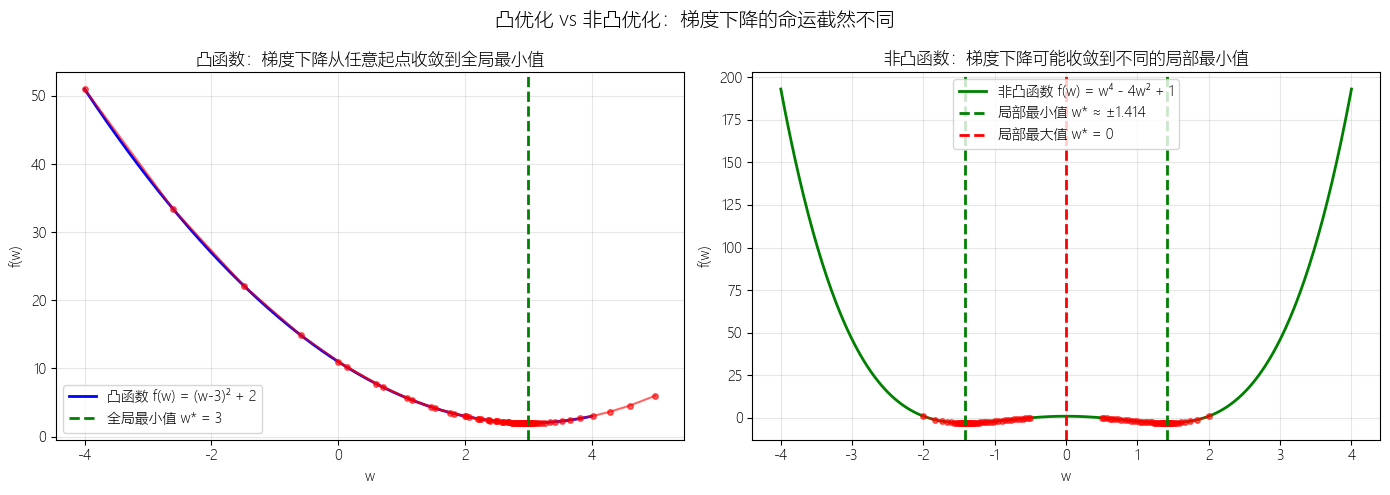

In [20]:
# 导入数值计算库，生成自变量、梯度迭代运算
import numpy as np
# 导入绘图库，绘制损失曲线、梯度下降迭代轨迹
import matplotlib.pyplot as plt

# ===================== 1. 定义凸损失函数及其解析梯度 =====================
# 凸二次函数：单一口碗，唯一全局最小值
def convex_loss(w):
    """凸损失函数 f(w) = (w-3)² + 2"""
    return (w - 3)**2 + 2

def convex_grad(w):
    """凸函数一阶导数（梯度）：df/dw = 2(w-3)"""
    return 2 * (w - 3)

# ===================== 2. 定义非凸损失函数及其解析梯度 =====================
# 四次多项式，双谷底+中间山峰，存在两个局部极小
def nonconvex_loss(w):
    """非凸损失函数 f(w) = w⁴ - 4w² + 1"""
    return w**4 - 4*w**2 + 1

def nonconvex_grad(w):
    """非凸函数一阶导数（梯度）：df/dw = 4w³ - 8w"""
    return 4*w**3 - 8*w

# ===================== 3. 通用梯度下降迭代函数 =====================
def gradient_descent(start, loss_func, grad_func, learning_rate, n_iterations):
    """
    标准批量梯度下降迭代器
    参数：
        start: 迭代初始权重w
        loss_func: 损失函数
        grad_func: 损失函数梯度
        learning_rate: 学习率，控制单步更新幅度
        n_iterations: 总迭代轮数
    返回：
        trajectory: 每一轮权重w的变化轨迹数组
        losses: 每一轮对应的损失值数组
    """
    # 初始化权重起点
    w = start
    # 存储权重轨迹、对应损失
    trajectory = [w]
    losses = [loss_func(w)]
    
    # 循环迭代更新参数
    for i in range(n_iterations):
        # 计算当前位置梯度
        grad = grad_func(w)
        # 梯度下降核心更新公式：w = w - lr * ∇f
        w = w - learning_rate * grad
        # 记录新权重与损失
        trajectory.append(w)
        losses.append(loss_func(w))
    
    return np.array(trajectory), np.array(losses)

# ===================== 4. 执行两组梯度下降模拟 =====================
# 固定随机种子，保证复现性（本代码无随机采样，仅规范写法）
np.random.seed(42)
# 设置统一迭代轮数
n_iterations = 50

# 凸函数：设置4个完全不同的起点 [-4, 0, 2, 5]
starts_cvx = [-4, 0, 2, 5]
trajectories_cvx = []
for start in starts_cvx:
    traj, _ = gradient_descent(start, convex_loss, convex_grad, 
                                  learning_rate=0.1, n_iterations=n_iterations)
    trajectories_cvx.append(traj)

# 非凸函数：设置4个分布在左右两侧的起点 [-2, -0.5, 0.5, 2]
starts_noncvx = [-2, -0.5, 0.5, 2]
trajectories_noncvx = []
for start in starts_noncvx:
    traj, _ = gradient_descent(start, nonconvex_loss, nonconvex_grad, 
                                  learning_rate=0.01, n_iterations=n_iterations)
    trajectories_noncvx.append(traj)

# ===================== 5. 控制台打印收敛结果对比 =====================
print("=== 凸 vs 非凸：梯度下降行为 ===")
print(f"凸函数 f(w) = (w-3)² + 2:")
print(f"  全局最小值在 w* = 3")
# 遍历凸函数各起点的最终收敛值
for i, start in enumerate(starts_cvx):
    print(f"  起点 {start:+.1f} → 终点 {trajectories_cvx[i][-1]:+.6f}")

print(f"\n非凸函数 f(w) = w⁴ - 4w² + 1:")
print(f"  局部最小值在 w* ≈ ±1.414（f≈-3）")
print(f"  局部最大值在 w* = 0（f = 1）")
# 遍历非凸函数各起点的最终收敛值
for i, start in enumerate(starts_noncvx):
    print(f"  起点 {start:+.1f} → 终点 {trajectories_noncvx[i][-1]:+.6f}")

# ===================== 6. 双栏可视化绘图 =====================
# 创建1行2张子图，画布尺寸宽14高5英寸
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 生成连续自变量区间 [-4,4]，500个点保证曲线平滑
w_range = np.linspace(-4, 4, 500)

# 左子图：凸函数可视化
axes[0].plot(w_range, convex_loss(w_range), 'b-', lw=2, label='凸函数 f(w) = (w-3)² + 2')
# 绘制所有起点的梯度下降轨迹（红色圆点连线）
for traj in trajectories_cvx:
    axes[0].plot(traj, convex_loss(traj), 'ro-', markersize=4, alpha=0.6)
# 绿色虚线标记唯一全局最优解位置w=3
axes[0].axvline(x=3, color='green', linestyle='--', lw=2, label='全局最小值 w* = 3')
axes[0].set_title('凸函数：梯度下降从任意起点收敛到全局最小值')
axes[0].set_xlabel('w'); axes[0].set_ylabel('f(w)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右子图：非凸函数可视化
axes[1].plot(w_range, nonconvex_loss(w_range), 'g-', lw=2, label='非凸函数 f(w) = w⁴ - 4w² + 1')
# 绘制所有起点的梯度下降轨迹
for traj in trajectories_noncvx:
    axes[1].plot(traj, nonconvex_loss(traj), 'ro-', markersize=4, alpha=0.6)
# 绿色虚线标记两个局部极小点 ±√2 ≈ ±1.414
axes[1].axvline(x=np.sqrt(2), color='green', linestyle='--', lw=2, 
               label='局部最小值 w* ≈ ±1.414')
axes[1].axvline(x=-np.sqrt(2), color='green', linestyle='--', lw=2)
# 红色虚线标记中间局部极大点w=0
axes[1].axvline(x=0, color='red', linestyle='--', lw=2, label='局部最大值 w* = 0')
axes[1].set_title('非凸函数：梯度下降可能收敛到不同的局部最小值')
axes[1].set_xlabel('w'); axes[1].set_ylabel('f(w)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 画布总标题
plt.suptitle('凸优化 vs 非凸优化：梯度下降的命运截然不同', fontsize=14)
# 自动调整子图间距，防止文字重叠遮挡
plt.tight_layout()
# 弹出图像窗口展示
plt.show()

**梯度下降实验现象**
### 凸函数实验结果
无论起点取 $-4、0、2、5$ 任意值，50轮迭代后全部收敛到 $w\approx3$；
梯度永远指向唯一谷底，不存在被困风险，训练结果稳定。

### 非凸函数实验结果
- 起点 $-2、-0.5$：收敛至左侧局部极小 $w\approx-1.414$；
- 起点 $0.5、2$：收敛至右侧局部极小 $w\approx+1.414$；
起点落在山脊左侧就困左谷、右侧就困右谷，无法自动跨越山脊抵达另一侧。

下面我们再来个3D的例子，构造“双盆地+山脊”非凸函数，看下标准梯度下降算法在非凸优化场景下的经典缺陷：陷入局部极小陷阱，无法抵达全局最优。

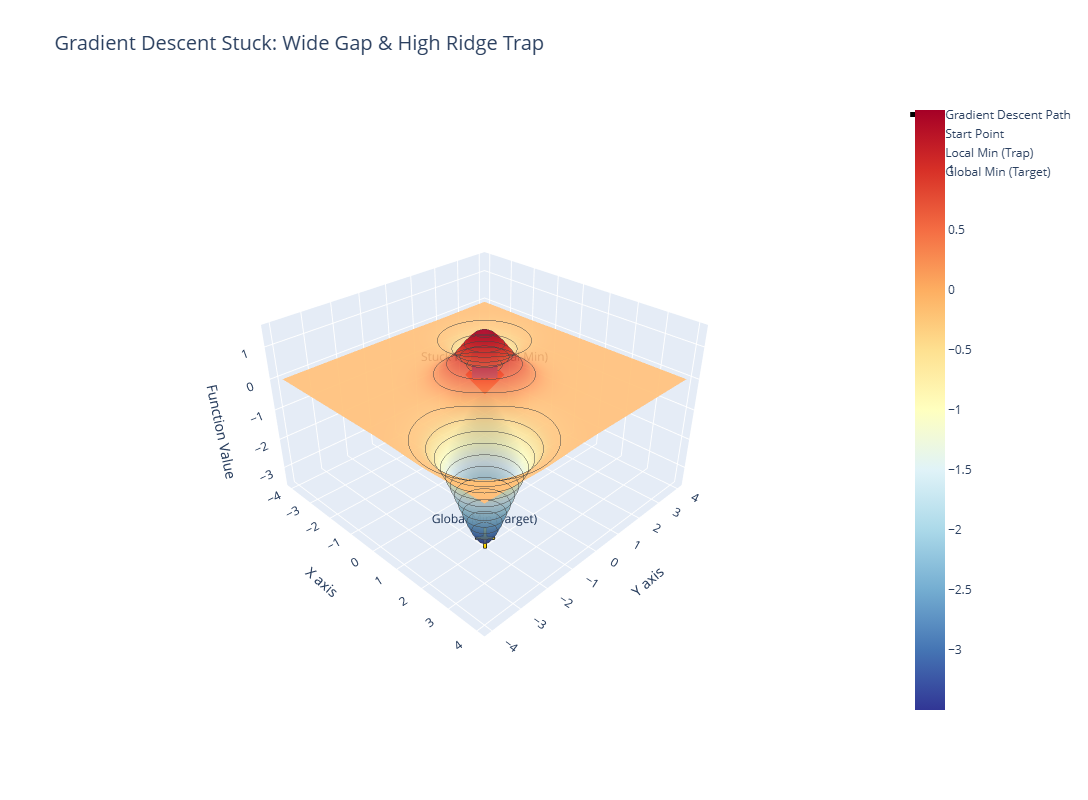

起始点: (-1.5, 1.5)
最终停止点: (-2.0005, 2.0005)
真正的全局最优点坐标: (1.99, -1.99)


In [16]:
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import griddata

# ====================== 1. 构造“双盆地+山脊”非凸函数 ======================
def crescent_function(x, y):
    """
    自定义二元非凸地形函数，三层高斯叠加构造陷阱地形：
    1. 左上浅坑：局部极小（梯度下降陷阱）
    2. 右下深坑：全局极小（真实最优解）
    3. 中间隆起山脊：两道盆地之间的高障碍，阻断梯度下降跨越
    输出z值越小代表损失越低
    """
    # 局部极小陷阱：左上(-2,2)浅洼地，系数-1.5，坑更浅
    trap = -1.5 * np.exp(-((x + 2)**2 + (y - 2)**2) / 0.8)
    
    # 全局极小目标：右下(2,-2)深洼地，系数-3.5，全局最低值
    global_min = -3.5 * np.exp(-((x - 2)**2 + (y + 2)**2) / 1.0)
    
    # 中间山脊障碍：原点(0,0)隆起高山，分隔两个盆地
    ridge = 1.5 * np.exp(-((x)**2 + (y)**2) / 1.0)
    
    # 三层叠加得到完整非凸曲面高度
    return trap + global_min + ridge

def grad_crescent(x, y, eps=1e-5):
    """
    中心差分法数值求梯度（无需手动解析求导，通用梯度计算）
    eps：微小扰动步长，平衡截断误差与浮点精度
    返回 [∂f/∂x, ∂f/∂y] 梯度向量
    """
    # 对x轴中心差分：[f(x+eps,y)-f(x-eps,y)] / 2eps
    gx = (crescent_function(x + eps, y) - crescent_function(x - eps, y)) / (2 * eps)
    # 对y轴中心差分：[f(x,y+eps)-f(x,y-eps)] / 2eps
    gy = (crescent_function(x, y + eps) - crescent_function(x, y - eps)) / (2 * eps)
    return np.array([gx, gy])

# ====================== 2. 梯度下降算法 ======================
def gradient_descent_trap(start_x, start_y, lr=0.1, n_iters=100, tol=1e-4):
    """
    标准批量梯度下降迭代器
    参数：
        start_x, start_y：迭代起点坐标
        lr：学习率，控制每一步更新幅度
        n_iters：最大迭代次数上限
        tol：收敛阈值，坐标变化小于该值判定收敛停止
    返回：
        path_x, path_y：完整迭代轨迹坐标数组
        (x, y)：最终收敛停留坐标
    """
    # 初始化迭代坐标
    x, y = start_x, start_y
    # 存储轨迹，先存入起点
    path_x, path_y = [x], [y]
    
    # 循环迭代更新参数
    for _ in range(n_iters):
        # 获取当前位置梯度
        g = grad_crescent(x, y)
        # 梯度下降核心更新公式：w = w - lr * ∇f
        x_new = x - lr * g[0]
        y_new = y - lr * g[1]
        
        # 保存新坐标到轨迹
        path_x.append(x_new)
        path_y.append(y_new)
        
        # 早停判断：新旧坐标欧氏距离小于阈值，判定收敛
        if np.sqrt((x_new - x)**2 + (y_new - y)**2) < tol:
            break
        # 更新迭代点，进入下一轮
        x, y = x_new, y_new
        
    return np.array(path_x), np.array(path_y), (x, y)

# ====================== 3. 运行模拟 ======================
# 迭代起点：左上区域，落在局部极小盆地范围内
start_point = (-1.5, 1.5) 
# 执行梯度下降，设置学习率0.15，最大迭代100次
path_x, path_y, final_pos = gradient_descent_trap(*start_point, lr=0.15, n_iters=100)

# ====================== 4. 交互式 3D 可视化 (Plotly) ======================
# 生成xy轴网格采样区间 [-4,4]，300个采样点保证曲面平滑
x_range = np.linspace(-4, 4, 300)
y_range = np.linspace(-4, 4, 300)
# 构建二维网格矩阵
X, Y = np.meshgrid(x_range, y_range)
# 批量计算网格所有点的曲面高度Z
Z = crescent_function(X, Y)

# 插值查询轨迹点对应的曲面Z值，+0.15抬高轨迹线，避免和曲面重叠遮挡
path_z = griddata((X.flatten(), Y.flatten()), Z.flatten(), (path_x, path_y), method='linear') + 0.15

# 创建Plotly画布对象
fig = go.Figure()

# 第一层：绘制3D损失曲面
fig.add_trace(go.Surface(
    x=X, y=Y, z=Z,
    colorscale='RdYlBu_r', # 红高蓝低配色：红色山脊，蓝色洼地
    opacity=0.85, # 半透明，方便看清下层等高线
    contours={"z": {"show": True, "start": -4, "end": 2, "size": 0.3}}, # 显示z轴等高线
    name="Non-Convex Terrain"
))

# 第二层：绘制梯度下降迭代轨迹（黑线+红色节点标记每一步）
fig.add_trace(go.Scatter3d(
    x=path_x, y=path_y, z=path_z,
    mode='lines+markers', # 同时显示连线和散点
    line=dict(color='black', width=5), # 粗黑色轨迹线
    marker=dict(size=4, color='red'), # 红色小点标记每一步迭代位置
    name='Gradient Descent Path'
))

# 第三层：标记迭代蓝色方形起点
fig.add_trace(go.Scatter3d(
    x=[path_x[0]], y=[path_y[0]], z=[path_z[0]],
    mode='markers',
    marker=dict(size=8, color='blue', symbol='square'),
    name='Start Point'
))

# 第四层：标记梯度下降卡住的局部极小值（红色菱形）
final_z = griddata((X.flatten(), Y.flatten()), Z.flatten(), (final_pos[0], final_pos[1]), method='linear') + 0.15
fig.add_trace(go.Scatter3d(
    x=[final_pos[0]], y=[final_pos[1]], z=[final_z],
    mode='markers+text', # 显示标记+文字标签
    marker=dict(size=10, color='red', symbol='diamond'),
    text=['Stuck Here! (Local Min)'],
    textposition='top center', # 文字显示在标记上方
    name='Local Min (Trap)'
))

# 第五层：自动搜寻全局最小值坐标并标记（金色十字）
min_idx = np.argmin(Z) # 找到Z矩阵最小值索引
global_min_x = X.flatten()[min_idx]
global_min_y = Y.flatten()[min_idx]
global_min_z = griddata((X.flatten(), Y.flatten()), Z.flatten(), (global_min_x, global_min_y), method='linear') + 0.15

fig.add_trace(go.Scatter3d(
    x=[global_min_x], y=[global_min_y], z=[global_min_z],
    mode='markers+text',
    marker=dict(size=10, color='gold', symbol='cross', line=dict(width=2, color='black')),
    text=['Global Min (Target)'],
    textposition='top center',
    name='Global Min (Target)'
))

# 全局画布布局、视角、尺寸配置
fig.update_layout(
    title=dict(text='Gradient Descent Stuck: Wide Gap & High Ridge Trap', font=dict(size=20)),
    scene=dict(
        xaxis_title='X axis',
        yaxis_title='Y axis',
        zaxis_title='Function Value',
        camera=dict(
            eye=dict(x=1.8, y=-1.8, z=1.5) # 固定3D观察视角
        )
    ),
    width=1000,
    height=800
)

# 弹出交互式3D图表，支持拖拽旋转、滚轮缩放、hover查看坐标数值
fig.show()

# 控制台打印关键坐标对比
print(f"起始点: {start_point}")
print(f"最终停止点: ({final_pos[0]:.4f}, {final_pos[1]:.4f})")
print(f"真正的全局最优点坐标: ({global_min_x:.2f}, {global_min_y:.2f})")

可以看到算法卡在了局部最小值（红色方块），没有找到Global Min（蓝色尖底下方的金色十字形）。这是由于梯度下降算法（GD）的本质是局部贪心，它只能感知当前位置的梯度（即脚下的坡度）。当小球从左上角滑落并进入浅坑后，由于四周皆是上坡，梯度趋近于零，算法便会误认为已经到达最低点，从而彻底“卡死”在局部极小值中。它缺乏跨越中间山脊所需的“全局视野”或“惯性”。

**理论本质**
1. **凸优化保证全局最优**
凸函数满足凸函数不等式，曲线全程向下凹陷，没有山脊、多盆地结构；梯度方向始终指向全局最低点，和初始化无关。
2. **非凸优化无全局最优保证**
曲面存在多个谷底、山脊屏障；梯度仅感知当前局部地形，无法“看见”远处更深的最优盆地，极易困在局部极小。

---

## 📝 本篇小结

| 概念 | 数学定义 | 在优化中的意义 |
|------|---------|-----------|
| **凸集** | θx + (1-θ)y ∈ C, ∀x,y∈C, θ∈[0,1] | 优化问题的「舞台」 |
| **凸函数** | f(θx+(1-θ)y) ≤ θf(x)+(1-θ)f(y) | 没有局部最小值，只有全局最小值 |
| **Fermat定理** | ∇f(x*) = 0 | 凸函数的驻点 = 全局最小值 |
| **Hessian正定** | ∇²f(x) ≻ 0 | 二阶条件：函数是凸的 |
| **凸优化** | 在凸集上最小化凸函数 | 梯度下降保证收敛到全局最小值 |

## 🏋️ 课后挑战

1. **证明**：f(x) = \|x\|₂（二范数）是凸函数。（提示：用三角不等式）
2. **验证**：逻辑回归的损失函数（对数损失）是凸函数吗？如果是，其 Hessian 矩阵是什么？

> 下期预告：约束优化与拉格朗日乘子法 —— 当优化问题有约束时，该怎么办？